In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
df = pd.read_csv("data/diabetes.csv", header=None, names=col_names)
df.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.drop(columns='label')
y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=1, stratify=y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

LogisticRegression()

In [8]:
print('Accuracy', logmodel.score(X_test, y_test))

Accuracy 0.7987012987012987


In [9]:
predictions = logmodel.predict(X_test)
# print(predictions)
# print(y_test)

In [10]:
cm = confusion_matrix(y_test, predictions)
print(cm)

tn, fp, fn, tp = cm.ravel()
print("TN", tn, "FP", fp, "FN", fn, "TP", tp)

[[88 12]
 [19 35]]
TN 88 FP 12 FN 19 TP 35


In [13]:
probs = logmodel.predict_proba(X_test)
#print(probs)
probs = probs[:,1]
print(probs)

[0.15421447 0.36676094 0.09059802 0.1349855  0.0655027  0.12260448
 0.49546201 0.74610918 0.64243514 0.42477728 0.01479746 0.33643845
 0.81668219 0.25433133 0.0832115  0.08602778 0.0583358  0.54083496
 0.29211643 0.05518911 0.25387974 0.71494136 0.06140612 0.66468548
 0.00405155 0.15881381 0.35504162 0.46012985 0.03858804 0.52546043
 0.03172164 0.16981978 0.3574784  0.11909008 0.67386914 0.17653554
 0.22702118 0.38440484 0.07357536 0.02426391 0.26288592 0.30796705
 0.28599661 0.64486514 0.22485667 0.99133179 0.74894736 0.06445842
 0.43117116 0.34468137 0.6589144  0.08241644 0.80873991 0.26209564
 0.26545103 0.45988714 0.28498998 0.08138358 0.72729726 0.08630787
 0.66502844 0.63591503 0.86999797 0.06841431 0.5143745  0.30428528
 0.12387731 0.43541074 0.70736127 0.23664632 0.92324266 0.16301325
 0.15696199 0.76943168 0.92279652 0.35284657 0.08384708 0.77068621
 0.59611803 0.05628582 0.47502924 0.96838039 0.68377741 0.72689644
 0.12648408 0.35005031 0.10180811 0.38598876 0.15092602 0.4532

Text(0, 0.5, 'True positive rate')

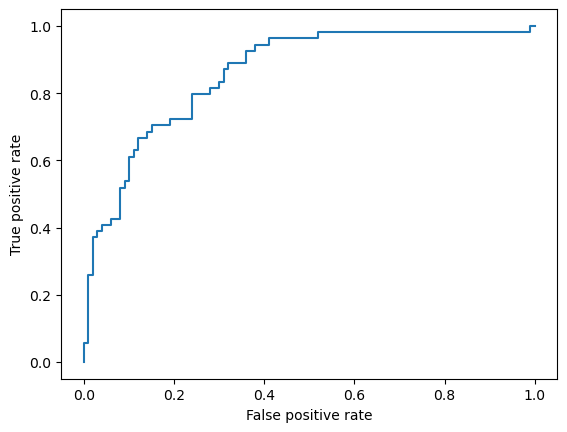

In [17]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

In [18]:
auc = roc_auc_score(y_test, probs)
print(auc)

0.8596296296296296
